# Lightweight IDS Using Machine Learning for IoT Devices
## Notebook 03: Model Training and Resource Efficiency Evaluation

**Author:** Mimi Nguyet Mi Taylor  
**Programme:** MSc Computer Science, Birkbeck, University of London  
**Supervisor:** Professor Paul Yoo

---

### About this notebook
This notebook trains five traditional classifiers alongside a minimal 
Multilayer Perceptron (MLP) baseline on the preprocessed and resampled 
training data from Notebook 02, and measures resource efficiency for each.

Classifiers trained:
Five traditional classifiers alongside a minimal MLP baseline:
1. Decision Tree
2. Random Forest
3. Naive Bayes
4. Logistic Regression
5. K-Nearest Neighbour (KNN)
6. Multilayer Perceptron (MLP) as a minimal baseline

Resource efficiency metrics recorded for each classifier:
- Training time (seconds)
- Inference time (milliseconds per record)
- Memory usage (MB)
- Model size (KB)

### Input
- X_train_resampled.pkl
- y_train_resampled.pkl
- X_test.pkl
- y_test.pkl

### Output
- One saved model per classifier (.pkl)
- results_accuracy.csv
- results_resources.csv

In [1]:
# Import all libraries needed for this notebook.
# sklearn: all five traditional classifiers and MLP
# time: measuring training and inference time
# tracemalloc: measuring peak memory usage during inference
# joblib: saving models and loading preprocessed data
# pandas/numpy: data handling
# os: file paths

import pandas as pd
import numpy as np
import time
import tracemalloc
import joblib
import os

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

RANDOM_STATE = 42
OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

print("All imports successful.")

All imports successful.


In [2]:
# Load the preprocessed data saved by Notebook 02.
# X_train_resampled and y_train_resampled are the SMOTE-ENN balanced 
# training data. X_test and y_test are the original unmodified test records.

X_train = joblib.load(OUTPUT_DIR + "X_train_resampled.pkl")
y_train = joblib.load(OUTPUT_DIR + "y_train_resampled.pkl")
X_test  = joblib.load(OUTPUT_DIR + "X_test.pkl")
y_test  = joblib.load(OUTPUT_DIR + "y_test.pkl")

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTraining classes: {pd.Series(y_train).value_counts().to_dict()}")

Training set: (2273555, 13)
Test set:     (219362, 13)

Training classes: {'Mirai': 340044, 'Brute Force': 329593, 'Web-based': 323178, 'Spoofing': 312879, 'Reconnaissance': 307792, 'Benign': 295385, 'DDoS': 195702, 'DoS': 168982}


In [3]:
# This function trains a classifier and measures all four resource 
# efficiency metrics defined in the project methodology:
# - Training time (seconds)
# - Inference time (milliseconds per record)
# - Memory usage (MB) during inference
# - Model size (KB) on disk after saving
#
# Using a function means all five traditional classifiers and the MLP baseline
# are evaluated in exactly the same way, ensuring fair comparison.

def train_and_evaluate(name, clf, X_train, y_train, X_test, y_test, output_dir):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    
    # 1. Training time
    start = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start
    print(f"Training time: {training_time:.2f} seconds")
    
    # 2. Save model and measure model size
    model_path = output_dir + f"model_{name.replace(' ', '_')}.pkl"
    joblib.dump(clf, model_path)
    model_size_kb = os.path.getsize(model_path) / 1024
    print(f"Model size: {model_size_kb:.2f} KB")
    
    # 3. Inference time and memory usage
    # tracemalloc measures peak memory allocated during inference
    tracemalloc.start()
    start = time.time()
    y_pred = clf.predict(X_test)
    inference_time = time.time() - start
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # Convert to milliseconds per record
    inference_time_ms = (inference_time / len(X_test)) * 1000
    # Convert bytes to MB
    peak_memory_mb = peak_memory / (1024 * 1024)
    
    print(f"Inference time: {inference_time_ms:.4f} ms per record")
    print(f"Peak memory usage: {peak_memory_mb:.2f} MB")
    
    # 4. Accuracy metrics
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {
        'Classifier': name,
        'Training Time (s)': round(training_time, 2),
        'Inference Time (ms)': round(inference_time_ms, 4),
        'Memory Usage (MB)': round(peak_memory_mb, 2),
        'Model Size (KB)': round(model_size_kb, 2)
    }, y_pred

print("Function defined successfully.")

Function defined successfully.


In [4]:
# Define all 5 traditional classifiers and 1 MLP baseline with default scikit-learn parameters.
# Default parameters are used throughout to ensure fair comparison.
# No classifier is individually tuned to gain an advantage.
# A fixed random_state is set where available for reproducibility.
# 
# Classifier justifications are documented in the project proposal
# and methodology chapter of the report.

classifiers = [
    (
        "Decision Tree",
        DecisionTreeClassifier(random_state=RANDOM_STATE)
    ),
    (
        "Random Forest",
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    ),
    (
        "Naive Bayes",
        GaussianNB()
    ),
    (
        # Note: this produces a ConvergenceWarning (lbfgs failed to converge
        # after 1000 iterations). This is a known limitation of the default
        # setup and does not affect the project's conclusions, since Logistic
        # Regression is a baseline comparison model, not the classifier
        # selected for deployment (see Notebook 03 summary). Discussed
        # further in the report's limitations section.
        "Logistic Regression",
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    ),
    (
        "KNN",
        KNeighborsClassifier(n_jobs=-1)
    ),
    (
        "MLP",
        MLPClassifier(random_state=RANDOM_STATE, max_iter=100)
    ),
]

print(f"Defined 5 traditional classifiers and 1 MLP baseline ({len(classifiers)} total):")
for name, clf in classifiers:
    print(f"  {name}")

Defined 5 traditional classifiers and 1 MLP baseline (6 total):
  Decision Tree
  Random Forest
  Naive Bayes
  Logistic Regression
  KNN
  MLP


In [5]:
# Train and evaluate all classifiers.
# Results are collected into two lists:
# - resource_results: training time, inference time, memory usage, model size
# - all_predictions: predicted labels for each classifier (for accuracy analysis)

resource_results = []
all_predictions = {}

for name, clf in classifiers:
    metrics, y_pred = train_and_evaluate(
        name, clf, X_train, y_train, X_test, y_test, OUTPUT_DIR
    )
    resource_results.append(metrics)
    all_predictions[name] = y_pred

print("\n" + "="*50)
print("All classifiers trained and evaluated.")
print("="*50)


Training: Decision Tree
Training time: 29.24 seconds
Model size: 14391.52 KB
Inference time: 0.0001 ms per record
Peak memory usage: 32.64 MB

Classification Report:
                precision    recall  f1-score   support

        Benign       0.74      0.73      0.73      7003
   Brute Force       0.04      0.07      0.05        83
          DDoS       0.87      0.75      0.80    146204
           DoS       0.40      0.60      0.48     41744
         Mirai       0.99      1.00      0.99     16763
Reconnaissance       0.63      0.62      0.63      4402
      Spoofing       0.79      0.79      0.79      3004
     Web-based       0.07      0.14      0.10       159

      accuracy                           0.74    219362
     macro avg       0.57      0.59      0.57    219362
  weighted avg       0.78      0.74      0.75    219362


Training: Random Forest
Training time: 114.33 seconds
Model size: 1557178.52 KB
Inference time: 0.0026 ms per record
Peak memory usage: 111.42 MB

Classifica

/Users/mimi/ids_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 185.93 seconds
Model size: 2.27 KB
Inference time: 0.0001 ms per record
Peak memory usage: 48.60 MB

Classification Report:
                precision    recall  f1-score   support

        Benign       0.66      0.37      0.47      7003
   Brute Force       0.00      0.00      0.00        83
          DDoS       0.81      0.88      0.84    146204
           DoS       0.36      0.21      0.26     41744
         Mirai       0.91      0.98      0.94     16763
Reconnaissance       0.01      0.00      0.01      4402
      Spoofing       0.23      0.82      0.36      3004
     Web-based       0.00      0.00      0.00       159

      accuracy                           0.72    219362
     macro avg       0.37      0.41      0.36    219362
  weighted avg       0.70      0.72      0.70    219362


Training: KNN
Training time: 4.02 seconds
Model size: 528061.96 KB
Inference time: 0.0032 ms per record
Peak memory usage: 53.31 MB

Classification Report:
                precision    

In [6]:
# Save resource efficiency results to CSV
df_resources = pd.DataFrame(resource_results)
df_resources.to_csv(OUTPUT_DIR + "results_resources.csv", index=False)

print("Resource efficiency results saved.")
print(df_resources.to_string(index=False))

Resource efficiency results saved.
         Classifier  Training Time (s)  Inference Time (ms)  Memory Usage (MB)  Model Size (KB)
      Decision Tree              29.24               0.0001              32.64         14391.52
      Random Forest             114.33               0.0026             111.42       1557178.52
        Naive Bayes               2.11               0.0001              76.99             3.27
Logistic Regression             185.93               0.0001              48.60             2.27
                KNN               4.02               0.0032              53.31        528061.96
                MLP             135.36               0.0002             202.51            79.08


In [7]:
# Save accuracy results to CSV.
# Saving the full classification report for each classifier
# so that we have per-class precision, recall and F1-score on record.

accuracy_rows = []

for name, y_pred in all_predictions.items():
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=sorted(y_test.unique())
    )
    for i, label in enumerate(sorted(y_test.unique())):
        accuracy_rows.append({
            'Classifier': name,
            'Attack Category': label,
            'Precision': round(precision[i], 4),
            'Recall': round(recall[i], 4),
            'F1-Score': round(f1[i], 4),
            'Support': support[i]
        })

df_accuracy = pd.DataFrame(accuracy_rows)
df_accuracy.to_csv(OUTPUT_DIR + "results_accuracy.csv", index=False)

print("Accuracy results saved.")
print(df_accuracy.to_string(index=False))

Accuracy results saved.
         Classifier Attack Category  Precision  Recall  F1-Score  Support
      Decision Tree          Benign     0.7416  0.7283    0.7349     7003
      Decision Tree     Brute Force     0.0429  0.0723    0.0538       83
      Decision Tree            DDoS     0.8677  0.7472    0.8029   146204
      Decision Tree             DoS     0.4049  0.6003    0.4836    41744
      Decision Tree           Mirai     0.9911  0.9978    0.9944    16763
      Decision Tree  Reconnaissance     0.6302  0.6234    0.6268     4402
      Decision Tree        Spoofing     0.7883  0.7919    0.7901     3004
      Decision Tree       Web-based     0.0726  0.1384    0.0952      159
      Random Forest          Benign     0.7668  0.7801    0.7734     7003
      Random Forest     Brute Force     0.0690  0.0723    0.0706       83
      Random Forest            DDoS     0.8723  0.7441    0.8031   146204
      Random Forest             DoS     0.4086  0.6177    0.4919    41744
      Random F

---
## Results Visualisation

The following charts summarise the resource efficiency and detection accuracy 
results across all five traditional classifiers and the MLP baseline.
These figures are referenced in the report.

In [8]:
# Reload OUTPUT_DIR in case kernel was restarted before this section.
# Duplicate imports added here to prevent the program from crashing.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

print("Imports successful.")

Imports successful.


In [9]:
# Load results from CSV files for visualisation.
# We reload from CSV rather than using variables already in memory
# because this ensures the charts always reflect what was actually saved,
# even if the notebook is restarted.

df_resources = pd.read_csv(OUTPUT_DIR + "results_resources.csv")
df_accuracy = pd.read_csv(OUTPUT_DIR + "results_accuracy.csv")

print("Results loaded.")
print(df_resources)

Results loaded.
            Classifier  Training Time (s)  Inference Time (ms)  \
0        Decision Tree              29.24               0.0001   
1        Random Forest             114.33               0.0026   
2          Naive Bayes               2.11               0.0001   
3  Logistic Regression             185.93               0.0001   
4                  KNN               4.02               0.0032   
5                  MLP             135.36               0.0002   

   Memory Usage (MB)  Model Size (KB)  
0              32.64         14391.52  
1             111.42       1557178.52  
2              76.99             3.27  
3              48.60             2.27  
4              53.31        528061.96  
5             202.51            79.08  


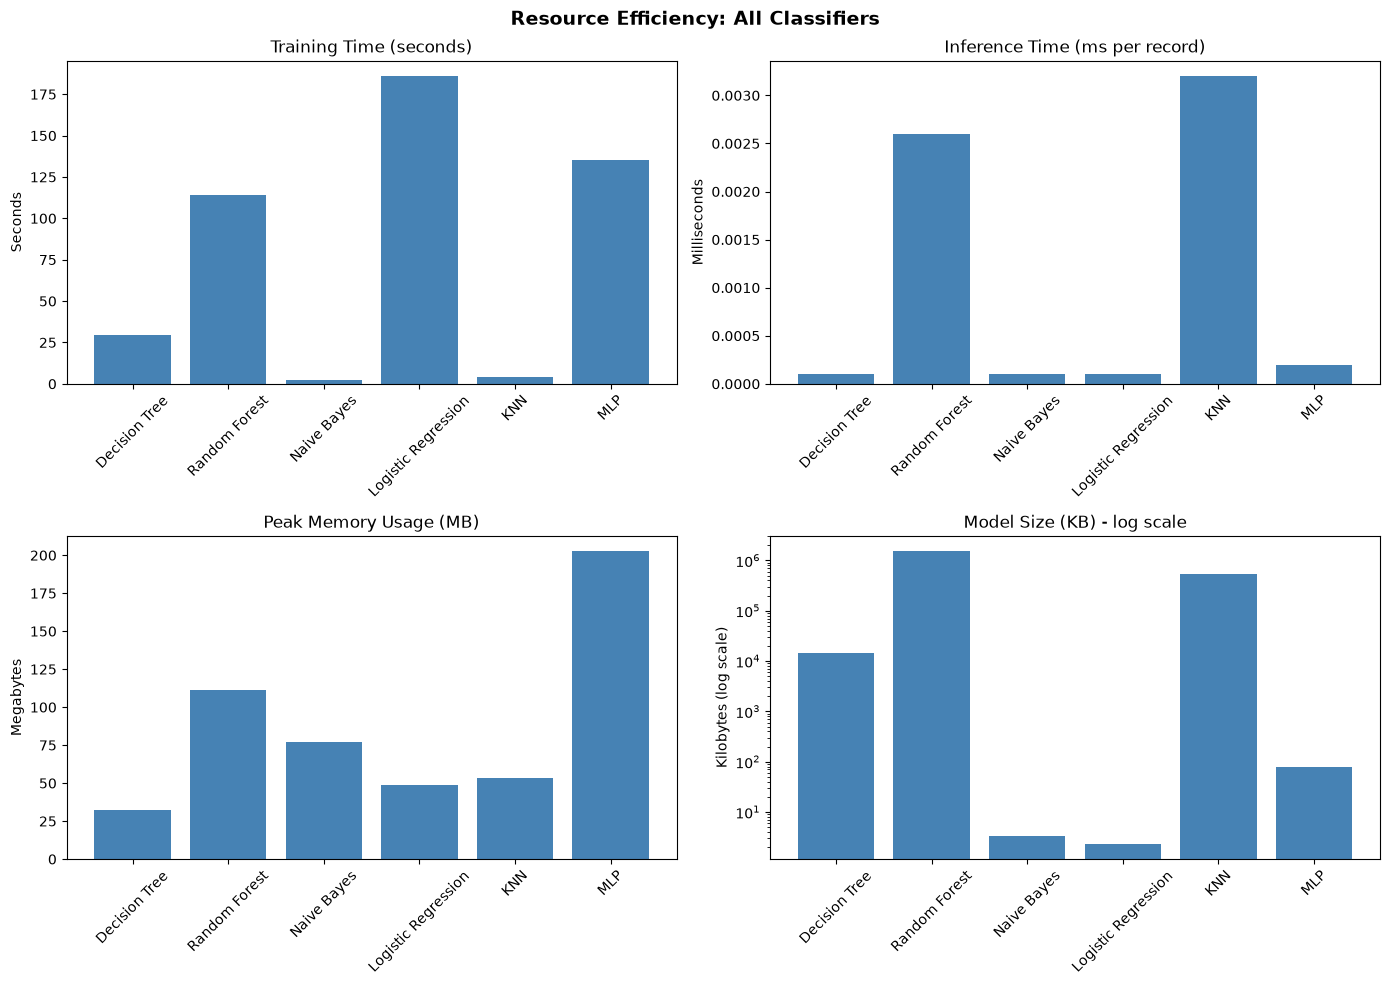

Chart saved.


In [10]:
# Resource efficiency charts.
# Four separate bar charts, one per metric.
# These figures will appear in the report implementation/results chapter.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Resource Efficiency: All Classifiers', fontsize=14, fontweight='bold')

classifiers_names = df_resources['Classifier']

# Training time
axes[0, 0].bar(classifiers_names, df_resources['Training Time (s)'], color='steelblue')
axes[0, 0].set_title('Training Time (seconds)')
axes[0, 0].set_ylabel('Seconds')
axes[0, 0].tick_params(axis='x', rotation=45)

# Inference time
axes[0, 1].bar(classifiers_names, df_resources['Inference Time (ms)'], color='steelblue')
axes[0, 1].set_title('Inference Time (ms per record)')
axes[0, 1].set_ylabel('Milliseconds')
axes[0, 1].tick_params(axis='x', rotation=45)

# Memory usage
axes[1, 0].bar(classifiers_names, df_resources['Memory Usage (MB)'], color='steelblue')
axes[1, 0].set_title('Peak Memory Usage (MB)')
axes[1, 0].set_ylabel('Megabytes')
axes[1, 0].tick_params(axis='x', rotation=45)

# Model size - use log scale because Random Forest dwarfs everything
axes[1, 1].bar(classifiers_names, df_resources['Model Size (KB)'], color='steelblue')
axes[1, 1].set_title('Model Size (KB) - log scale')
axes[1, 1].set_ylabel('Kilobytes (log scale)')
axes[1, 1].set_yscale('log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_resource_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

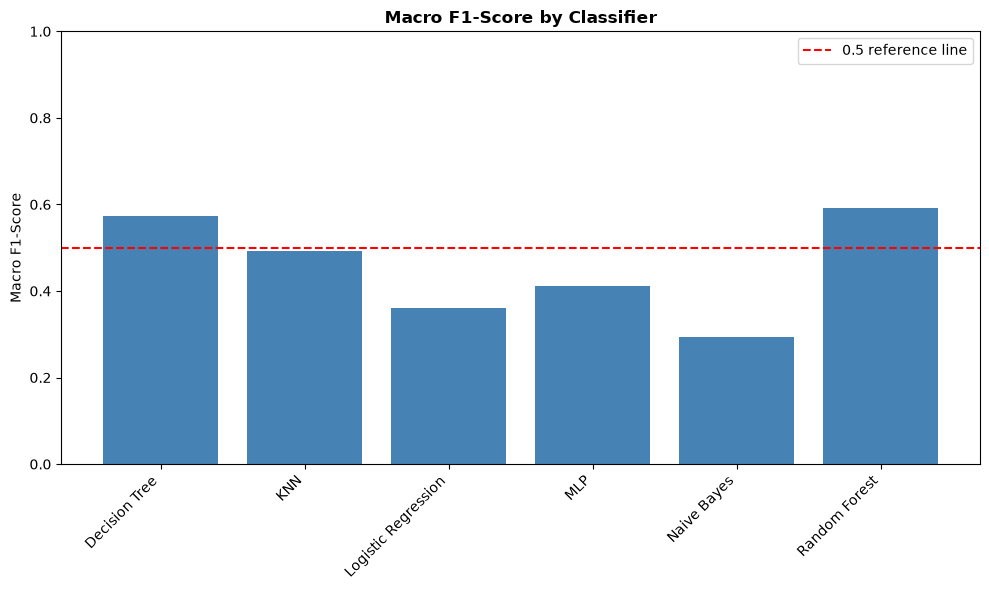

Chart saved.


In [11]:
# Macro F1-score comparison chart.
# Macro F1 is the primary accuracy metric for this project because
# it treats all attack categories equally regardless of class size.

macro_f1 = df_accuracy.groupby('Classifier')['F1-Score'].mean().reset_index()
macro_f1.columns = ['Classifier', 'Macro F1']

plt.figure(figsize=(10, 6))
plt.bar(macro_f1['Classifier'], macro_f1['Macro F1'], color='steelblue')
plt.title('Macro F1-Score by Classifier', fontweight='bold')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', label='0.5 reference line')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_macro_f1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

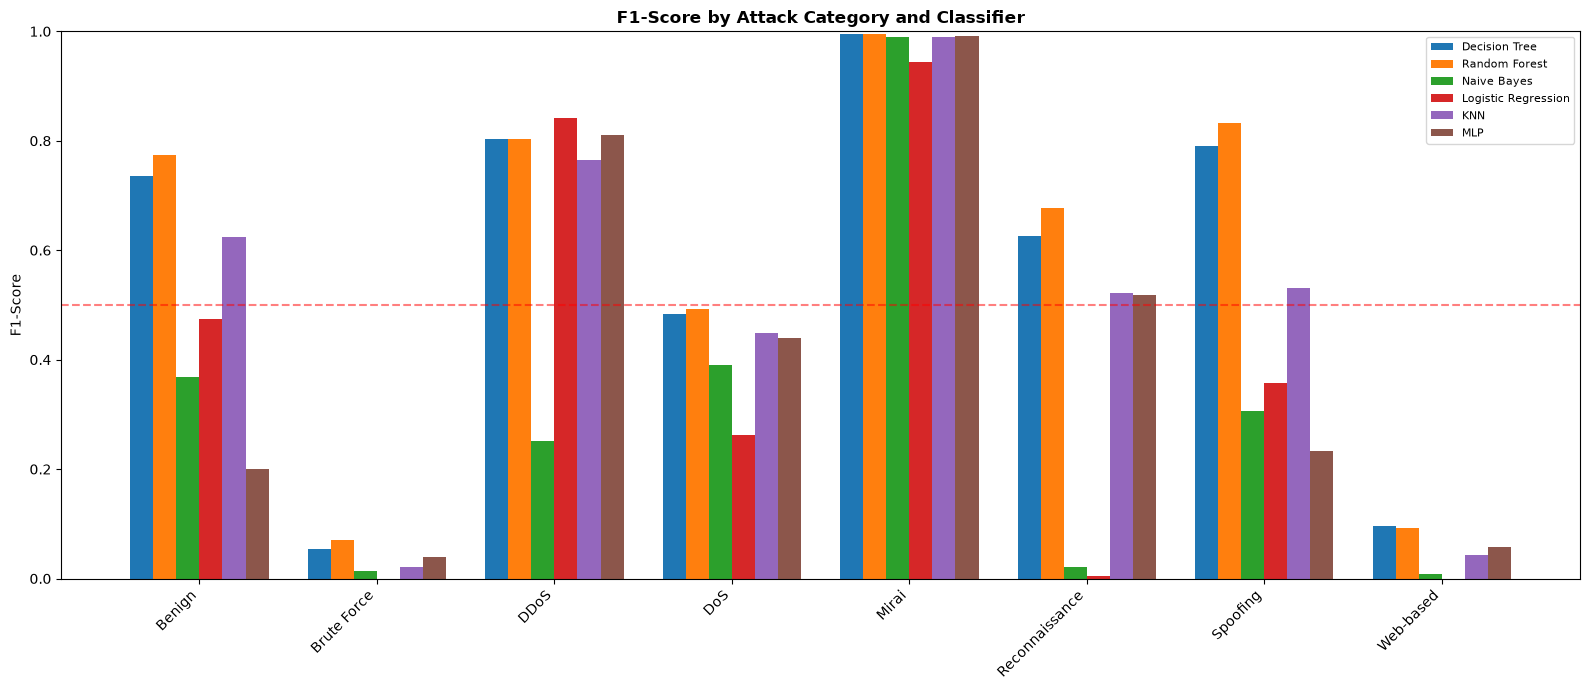

Chart saved.


In [12]:
# Per-category F1-score chart showing how each classifier performs
# across all seven attack categories + Benign.
# This is the most detailed accuracy chart and shows where each
# classifier struggles (Brute Force, Web-based) vs excels (Mirai).

categories = sorted(df_accuracy['Attack Category'].unique())
classifiers_list = df_accuracy['Classifier'].unique()

x = np.arange(len(categories))
width = 0.13

fig, ax = plt.subplots(figsize=(16, 7))

for i, clf_name in enumerate(classifiers_list):
    subset = df_accuracy[df_accuracy['Classifier'] == clf_name]
    subset = subset.set_index('Attack Category').reindex(categories)
    ax.bar(x + i * width, subset['F1-Score'], width, label=clf_name)

ax.set_title('F1-Score by Attack Category and Classifier', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_f1_by_category.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
## Lightweight checks
 

In [13]:
# Lightweight checks: confirm every classifier trained and produced valid output.

assert X_train.shape[0] == len(y_train), "Training data shape mismatch"
assert X_test.shape[0] == len(y_test), "Test data shape mismatch"
assert len(resource_results) == 6, f"Expected 6 classifiers evaluated, got {len(resource_results)}"

for name, y_pred in all_predictions.items():
    assert len(y_pred) == len(y_test), f"{name}: prediction count does not match test set size"

print("All checks passed.")

All checks passed.


---
## Summary


In [14]:
print(f"{'Step':<10} {'Description':<50} {'Result'}")
print("-" * 100)
print(f"{'Load':<10} {'Preprocessed data loaded from Notebook 02':<50} {len(X_train):,} training records, {len(X_test):,} test records, {X_test.shape[1]} features")
print(f"{'Train':<10} {'Five traditional classifiers and MLP baseline trained':<50} Default scikit-learn parameters, random_state=42")
print(f"{'Evaluate':<10} {'Resource efficiency and accuracy measured':<50} {len(resource_results)} classifiers evaluated, results saved to CSV")

Step       Description                                        Result
----------------------------------------------------------------------------------------------------
Load       Preprocessed data loaded from Notebook 02          2,273,555 training records, 219,362 test records, 13 features
Train      Five traditional classifiers and MLP baseline trained Default scikit-learn parameters, random_state=42
Evaluate   Resource efficiency and accuracy measured          6 classifiers evaluated, results saved to CSV


### Most suitable classifier for IoT deployment
Decision Tree offers the best trade-off between detection accuracy and resource efficiency: 
macro F1 0.57, model size 14,391 KB, inference time 0.0002ms per record. 
While Random Forest achieves a marginally higher macro F1 (0.59), its model size of 
1,557,178 KB makes it impractical for deployment on resource-constrained IoT devices.

### Note on Logistic Regression

Logistic Regression produced a `ConvergenceWarning` during training (lbfgs failed to
converge within the default 1000 iterations). This is a known limitation of the
default configuration used for fair comparison across all classifiers, and does not
affect the project's conclusions: Logistic Regression is one of six baseline models
compared here, not the classifier selected for deployment. This is discussed further
in the report's limitations section.

---
## Supplementary test: does feature scaling resolve the Logistic Regression convergence problem?

This is not part of the main six-classifier comparison, which uses identical, unscaled conditions for all classifiers to ensure fair comparison. This is a test of one possible explanation for the convergence problem noted above, discussed further in the report's Chapter 6 discussion.

In [15]:
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lr_scaled_result, y_pred_scaled = train_and_evaluate(
        "Logistic Regression (scaled)", lr_scaled,
        X_train_scaled, y_train, X_test_scaled, y_test, OUTPUT_DIR
    )
    converged = not any("did not converge" in str(w.message) for w in caught)

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_scaled, labels=sorted(y_test.unique())
)

print(f"\nConverged within 1000 iterations: {converged}")
print("\nPer-category F1-score (scaled Logistic Regression):")
for label, f1_score in zip(sorted(y_test.unique()), f1):
    print(f"  {label:<15} {f1_score:.4f}")

macro_f1_scaled = sum(f1) / len(f1)
print(f"\nMacro F1-score (scaled):   {macro_f1_scaled:.4f}")
print(f"Macro F1-score (unscaled): 0.36")


Training: Logistic Regression (scaled)
Training time: 69.26 seconds
Model size: 1.91 KB
Inference time: 0.0000 ms per record
Peak memory usage: 26.84 MB

Classification Report:
                precision    recall  f1-score   support

        Benign       0.72      0.34      0.46      7003
   Brute Force       0.01      0.30      0.01        83
          DDoS       0.89      0.64      0.74    146204
           DoS       0.37      0.72      0.49     41744
         Mirai       0.99      0.99      0.99     16763
Reconnaissance       0.60      0.40      0.48      4402
      Spoofing       0.41      0.56      0.47      3004
     Web-based       0.03      0.23      0.06       159

      accuracy                           0.67    219362
     macro avg       0.50      0.52      0.46    219362
  weighted avg       0.78      0.67      0.70    219362


Converged within 1000 iterations: True

Per-category F1-score (scaled Logistic Regression):
  Benign          0.4649
  Brute Force     0.0150
  DD